# Phase 6 - Monitoring, Drift Detection & Governance

*Hospital Operations & Revenue Risk Intelligence Platform*

**Goal:** long-term reliability and compliance for the deployed models - a
request validation gate, drift monitoring off the Phase 5 prediction log, a
scheduled drift job with threshold alerts, an append-only audit trail, and the
governance documents.

This notebook is thin: all reusable logic lives in `capstone.monitoring`; the
phase-local helpers are `seed_traffic` (demo traffic), `make_charts` and
`report`. It runs top-to-bottom from a clean kernel and is safe to re-run
(seeding is idempotent).

**Inputs:** `capstone_solution.prediction_log` (Phase 5), the persisted Phase 3
models + `phase5_api/serving_config.json`, `phase2_eda/output/feature_frame.parquet`,
`capstone_solution.v_visit_billing` (actual outcomes).
**Outputs:** `capstone_solution.drift_report`, `phase6_monitoring/output/`
(CSVs, `charts/`), `phase6_monitoring/PHASE6_FINDINGS.md`.

In [1]:
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from capstone import modeling as M, monitoring as mon, serving as S, viz
from capstone.db import connect, engine
import seed_traffic, make_charts, report

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
viz.apply_house_style()

HERE = Path.cwd()
OUT = HERE / "output"; (OUT / "charts").mkdir(parents=True, exist_ok=True)
FINDINGS_MD = HERE / "PHASE6_FINDINGS.md"

bundle = S.load_serving_bundle()
config = bundle.config
print("serving_version", config["serving_version"], "| model_version", config["model_version"])

serving_version 1.0.0 | model_version 1.0.0


## 1. Apply the DDL and seed two comparable traffic windows

`prediction_log` only fills from live API calls, so we replay real Phase 3 **test-window** visits through the exact serving path the API uses. The **baseline** window is un-perturbed; the **drifted** window applies a deliberate shift - billed amounts +60%, department mix toward ER, one insurer over-represented, patients ~12 years older, and a volume spike. Seeding is idempotent (prior `phase6-seed:*` rows are removed first).

In [2]:
with connect() as conn:
    mon.ensure_tables(conn)
    seed = seed_traffic.seed_all(conn)
seed

{'removed_prior': 0,
 'baseline_requests': 1800,
 'drift_requests': 2800,
 'baseline_visits': 900,
 'drift_visits': 1400,
 'model_version': '1.0.0'}

## 2. The drift reference and the monitored feature set

The reference is the Phase 3 **test** split (the most recent window the models were validated on; the training window's calendar features are disjoint from any later window by construction). Each model monitors exactly its Phase 3 manifest feature list, so Model A is never compared on a billing distribution.

In [3]:
ref = mon.reference_frame()
ref_label = mon.reference_label(ref)
monitored = {m: dict(zip(("numeric", "categorical"),
                         (len(a), len(b)))) for m in ("A", "B")
             for a, b in [mon.monitored_features(bundle, m)]}
print(ref_label)
pd.DataFrame(monitored).T

phase3-test 2025-11-20..2026-01-20


,numeric,categorical
A,13,9
B,16,13


## 3. Request validation gate

The Phase 2 data-quality rules (`capstone.data_quality`) reused as a batch gate over served request payloads: the enum domains and the pre-submission numeric ranges. A clean batch passes; a batch with bad enums / a negative amount / an out-of-range age is rejected, each offence named.

In [4]:
def _payloads(n, seed):
    rng = np.random.default_rng(seed)
    df = pd.read_parquet(S.PHASE2_PARQUET)
    df["visit_date"] = pd.to_datetime(df["visit_date"])
    test = M.time_split(df).test
    idx = rng.choice(len(test), size=n, replace=False)
    return [mon.feature_row_to_payload(r, "B") for _, r in test.iloc[idx].iterrows()]

clean = _payloads(120, 1)
bad = _payloads(60, 2)
for i, p in enumerate(bad):                       # corrupt ~half the batch
    if i % 2 == 0:
        p["department"] = "Radiology"             # not in the domain
    if i % 3 == 0:
        p["age"] = 210                            # out of range
    if i % 5 == 0:
        p["billed_amount"] = -500.0               # negative

gate_ok = mon.validation_gate(pd.json_normalize(clean).assign(request_id=range(len(clean))))
gate_bad = mon.validation_gate(pd.json_normalize(bad).assign(request_id=range(len(bad))))
print(f"clean  : fail_rate {gate_ok.fail_rate:.1%}  passed={gate_ok.passed}")
print(f"bad    : fail_rate {gate_bad.fail_rate:.1%}  passed={gate_bad.passed}")
display(gate_bad.offences)

clean  : fail_rate 0.0%  passed=True
bad    : fail_rate 73.3%  passed=False


,rule,severity,description,n_offending
0,gender_enum,ERROR,"gender outside {M,F}",0
1,visit_type_enum,ERROR,"visit_type outside {ER,OPD,ICU}",0
2,risk_score_enum,ERROR,"risk_score outside {Low,Medium,High}",0
3,department_enum,WARN,department not in the known set,30
4,city_enum,WARN,city not in the known set,0
5,provider_enum,WARN,insurance_provider not in the known set,0
6,age_range,ERROR,"age outside [0, 120]",20
7,billed_negative,ERROR,billed_amount < 0,12
8,los_negative,ERROR,length_of_stay_hours < 0,0


## 4. Run the drift job - baseline vs drifted window, both models

`mon.run_drift` pulls a window from `prediction_log`, rebuilds the served feature rows with `capstone.serving.build_model_row`, computes feature / prediction / gate / performance drift, and returns the rows `write_drift_report` persists. Each window gets one `run_id` covering both models (the shape a scheduled run takes).

In [5]:
import uuid
res = {}
with connect() as conn:
    from capstone import eda
    spine = eda.load_spine()
    written = 0
    for window in ("baseline", "drift"):
        rid = str(uuid.uuid4())
        for model in ("A", "B"):
            r = mon.run_drift(conn, bundle, model=model, window=window,
                              reference=ref, spine=spine, run_id=rid)
            written += mon.write_drift_report(conn, r)
            res[(model, window)] = r
statuses = pd.DataFrame(
    [{"model": m, "window": w, "n": res[(m, w)].window_n,
      "status": res[(m, w)].status, "alerts": len(res[(m, w)].alerts)}
     for m in ("A", "B") for w in ("baseline", "drift")])
print(f"{written} rows written to drift_report")
statuses

184 rows written to drift_report


,model,window,n,status,alerts
0,A,baseline,900,OK,0
1,A,drift,1400,ALERT,4
2,B,baseline,900,OK,0
3,B,drift,1400,ALERT,9


## 5. Feature drift

Model B monitored features, PSI vs the test-window reference. The baseline window stays inside the stable band; the drifted window trips billed amount, department, insurer and age past the significant line.

In [6]:
feat_baseline = res[("B", "baseline")].feature
feat_drift = res[("B", "drift")].feature
display(Markdown("**Baseline window** (top 8 by PSI)"))
display(feat_baseline.head(8))
display(Markdown("**Drifted window** (top 10 by PSI)"))
display(feat_drift.head(10))

**Baseline window** (top 8 by PSI)

,feature,kind,psi,ks_stat,ks_pvalue,band,drifted
0,age,numeric,0.021093,0.023991,0.775286,stable,False
1,week_of_year,numeric,0.012368,0.025149,0.724087,stable,False
2,billed_amount,numeric,0.009708,0.022144,0.850311,stable,False
3,log_billed_amount,numeric,0.009708,0.022144,0.850311,stable,False
4,length_of_stay_hours,numeric,0.009019,0.042645,0.129819,stable,False
5,provider_prior_rejection_rate,numeric,0.008762,0.029264,0.536889,stable,False
6,insurance_provider,categorical,0.008609,NaN,NaN,stable,False
7,prior_visit_count,numeric,0.007595,0.024491,0.753425,stable,False


**Drifted window** (top 10 by PSI)

,feature,kind,psi,ks_stat,ks_pvalue,band,drifted
0,insurance_provider,categorical,0.728441,NaN,NaN,significant,True
1,department,categorical,0.669454,NaN,NaN,significant,True
2,billed_amount,numeric,0.563921,0.311714,4.444278e-91,significant,True
3,log_billed_amount,numeric,0.563921,0.311714,4.444278e-91,significant,True
4,age,numeric,0.495330,0.290899,3.423107e-79,significant,True
5,age_band,categorical,0.465842,NaN,NaN,significant,True
6,billed_band,categorical,0.403016,NaN,NaN,significant,True
7,billed_at_floor,categorical,0.044656,NaN,NaN,stable,False
8,week_of_year,numeric,0.006180,0.018327,8.629020e-01,stable,False
9,days_since_last_visit,numeric,0.005254,0.013101,9.926389e-01,stable,False


## 6. Prediction-distribution drift

In [7]:
pm = (res[("B", "baseline")].prediction[["predicted_class", "reference_share", "current_share"]]
      .rename(columns={"current_share": "baseline_share"}))
pm["drift_share"] = res[("B", "drift")].prediction["current_share"].to_numpy()
pred_psi_baseline = float(res[("B", "baseline")].prediction["mix_psi"].iloc[0])
pred_psi_drift = float(res[("B", "drift")].prediction["mix_psi"].iloc[0])
print(f"predicted-mix PSI  baseline {pred_psi_baseline:.3f}  drift {pred_psi_drift:.3f}  "
      f"(alert > {mon.ALERT_RULES['prediction_psi']})")
pm

predicted-mix PSI  baseline 0.001  drift 0.244  (alert > 0.2)


,predicted_class,reference_share,baseline_share,drift_share
0,Paid,0.341549,0.334444,0.574286
1,Pending,0.232394,0.247778,0.192143
2,Rejected,0.426056,0.417778,0.233571


## 7. Performance drift

Actual `claim_status` joined back to the served predictions on the caller-supplied `visit_id`. Model B's monitored business metric is recall on Rejected claims at the operating threshold, against the Phase 4 baseline of 62%.

In [8]:
perf = {
    "operating_threshold": mon.PHASE4_BASELINE["B"]["operating_threshold"],
    "recall_baseline": mon.PHASE4_BASELINE["B"]["recall_costly"],
    "recall_baseline_window": res[("B", "baseline")].performance.get("recall_costly", float("nan")),
    "recall_drift_window": res[("B", "drift")].performance.get("recall_costly", float("nan")),
    "precision_drift_window": res[("B", "drift")].performance.get("precision_costly", float("nan")),
    "recall_breach": res[("B", "drift")].performance.get("recall_breach", False),
}
pd.Series(perf).to_frame("value")

,value
operating_threshold,0.19
recall_baseline,0.62
recall_baseline_window,0.622047
recall_drift_window,0.283422
precision_drift_window,0.161585
recall_breach,True


## 8. Governance and audit

`v_prediction_audit` joins every prediction to any manual override. We insert one example override, read it back through the view, and confirm the append-only trigger blocks an `UPDATE`.

In [9]:
_REASON = "Provider flagged prior-auth mismatch not visible to the model"
_ACTOR = "claims.lead@hospital.example"
with connect() as conn, conn.cursor() as cur:
    cur.execute("""SELECT request_id::text, predicted_class FROM capstone_solution.prediction_log
                   WHERE client_host = 'phase6-seed:drift' AND model = 'B'
                   ORDER BY ts DESC LIMIT 1""")
    rid_over, orig = cur.fetchone()
    cur.execute("""INSERT INTO capstone_solution.prediction_override
        (request_id, model, original_class, override_class, actor, reason)
        VALUES (%s, 'B', %s, 'Rejected', %s, %s)""", (rid_over, orig, _ACTOR, _REASON))
    conn.commit()
    try:
        cur.execute("UPDATE capstone_solution.drift_report SET value = 0 "
                    "WHERE id = (SELECT min(id) FROM capstone_solution.drift_report)")
        append_only = "NOT enforced - UPDATE succeeded"
    except Exception as exc:
        conn.rollback()
        append_only = f"enforced: {str(exc).splitlines()[0]}"

override_example = {"actor": _ACTOR, "original_class": orig,
                    "override_class": "Rejected", "reason": _REASON}
eng = engine()
try:
    audit_sample = pd.read_sql(
        """SELECT request_id, predicted_at, model, model_version, predicted_class,
                  override_class, override_actor, was_overridden
           FROM capstone_solution.v_prediction_audit
           WHERE client_host LIKE 'phase6-seed:%%'
           ORDER BY was_overridden DESC, predicted_at DESC LIMIT 5""", eng)
finally:
    eng.dispose()
print("append-only:", append_only)
audit_sample

append-only: enforced: capstone_solution.drift_report is immutable (attempted UPDATE)


,request_id,predicted_at,model,model_version,predicted_class,override_class,override_actor,was_overridden
0,8ed0a10f-730d-4426-af47-df7391cf2b88,2026-09-04 10:24:49.059499+00:00,B,1.0.0,Paid,Rejected,claims.lead@hospital.example,True
1,722d3ddc-e5df-4f48-80c1-2ffcb3b04b73,2026-09-04 10:24:49.059499+00:00,A,1.0.0,Low,NaN,NaN,False
2,43d3ad73-d371-4766-86c4-1f84cfdd7f80,2026-09-04 10:17:39.937444+00:00,B,1.0.0,Pending,NaN,NaN,False
3,f9bc5ae3-0b50-45f7-a6fe-083bf232ca48,2026-09-04 10:17:39.937444+00:00,A,1.0.0,Low,NaN,NaN,False
4,2162e52a-d074-4319-9b44-c151c1f2ccba,2026-09-04 10:10:30.815388+00:00,B,1.0.0,Paid,NaN,NaN,False


## 9. Charts, findings and the exit-criteria table

Every finding is backed by a house-style chart (`capstone.viz`); `make_charts.build_all` also writes the CSV exports. The Grafana dashboard (`phase6_monitoring/grafana/`) is the live operational view of the same `drift_report` / `prediction_log` data.

In [10]:
all_rows = pd.concat([res[k].report_rows for k in res], ignore_index=True)
baseline_alerts = len(res[("A", "baseline")].alerts) + len(res[("B", "baseline")].alerts)
drift_alerts = len(res[("A", "drift")].alerts) + len(res[("B", "drift")].alerts)

ctx = report.Phase6Context(
    generated=datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"),
    config=config, reference_window=ref_label, monitored_counts=monitored,
    gate_ok_n=gate_ok.n, gate_bad_n=gate_bad.n,
    gate_ok_fail_rate=gate_ok.fail_rate, gate_bad_fail_rate=gate_bad.fail_rate,
    gate_offences=gate_bad.offences,
    feat_baseline=feat_baseline, feat_drift=feat_drift,
    prediction_mix=pm, pred_psi_baseline=pred_psi_baseline, pred_psi_drift=pred_psi_drift,
    performance_drift=perf,
    drift_rows=all_rows,
    baseline_status=res[("B", "baseline")].status, drift_status=res[("B", "drift")].status,
    baseline_alert_count=baseline_alerts, drift_alert_count=drift_alerts,
    runs_written=written,
    audit_sample=audit_sample, override_example=override_example,
    seed_summary=seed,
)
charts = make_charts.build_all(ctx)
_C = {k: p for k, p, _ in charts}
report.write_findings(ctx, charts, FINDINGS_MD)
list(_C)

['gate_offences',
 'feature_psi_baseline',
 'feature_psi_drift',
 'prediction_mix',
 'performance_drift',
 'alert_summary']

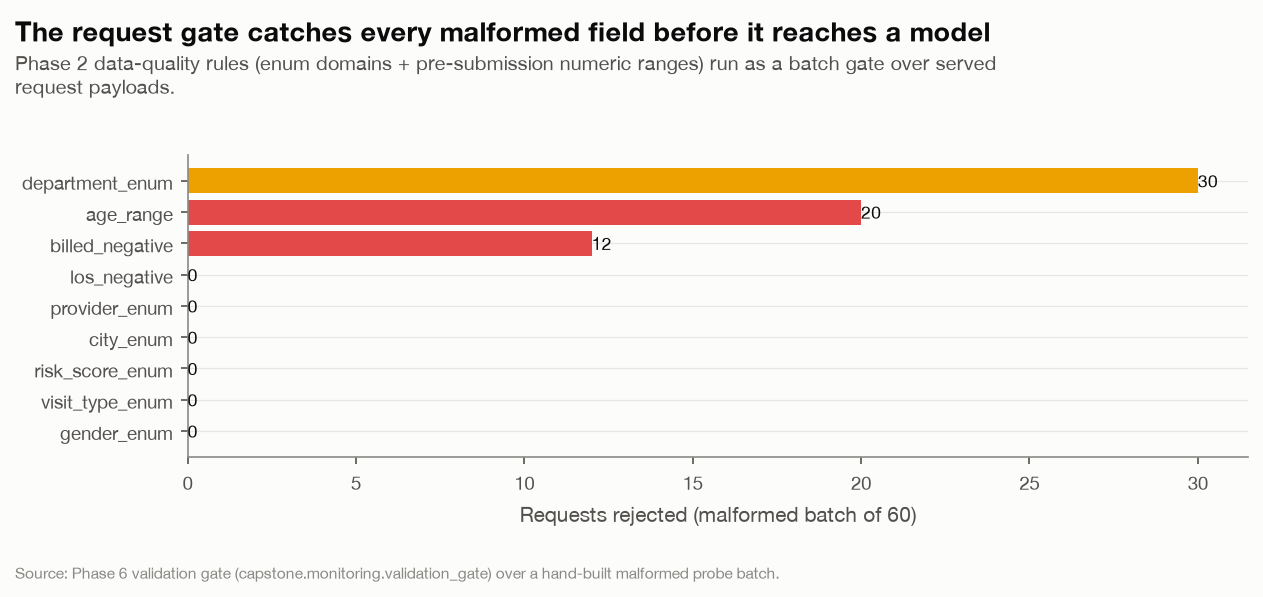

In [11]:
Image(str(_C["gate_offences"]))

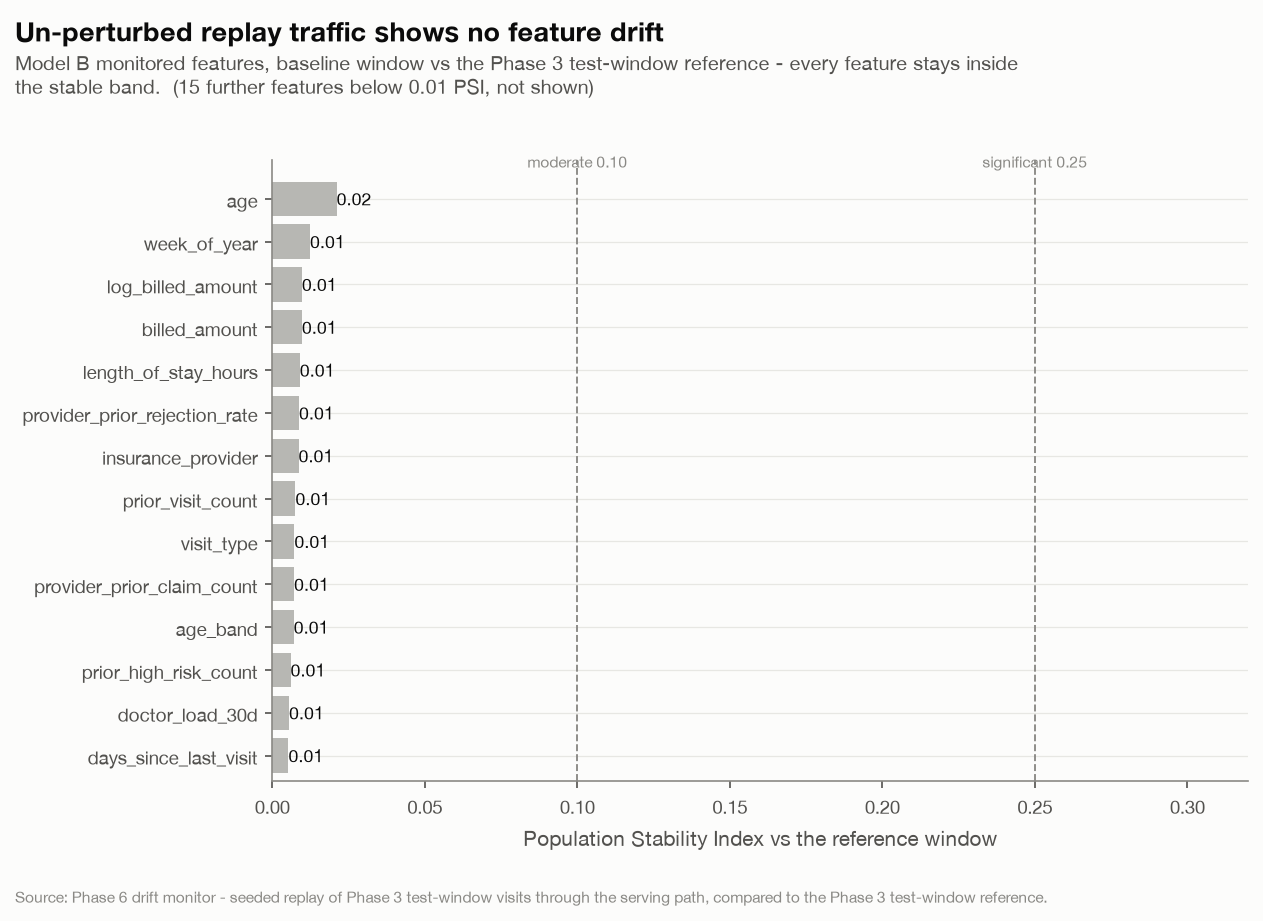

In [12]:
Image(str(_C["feature_psi_baseline"]))

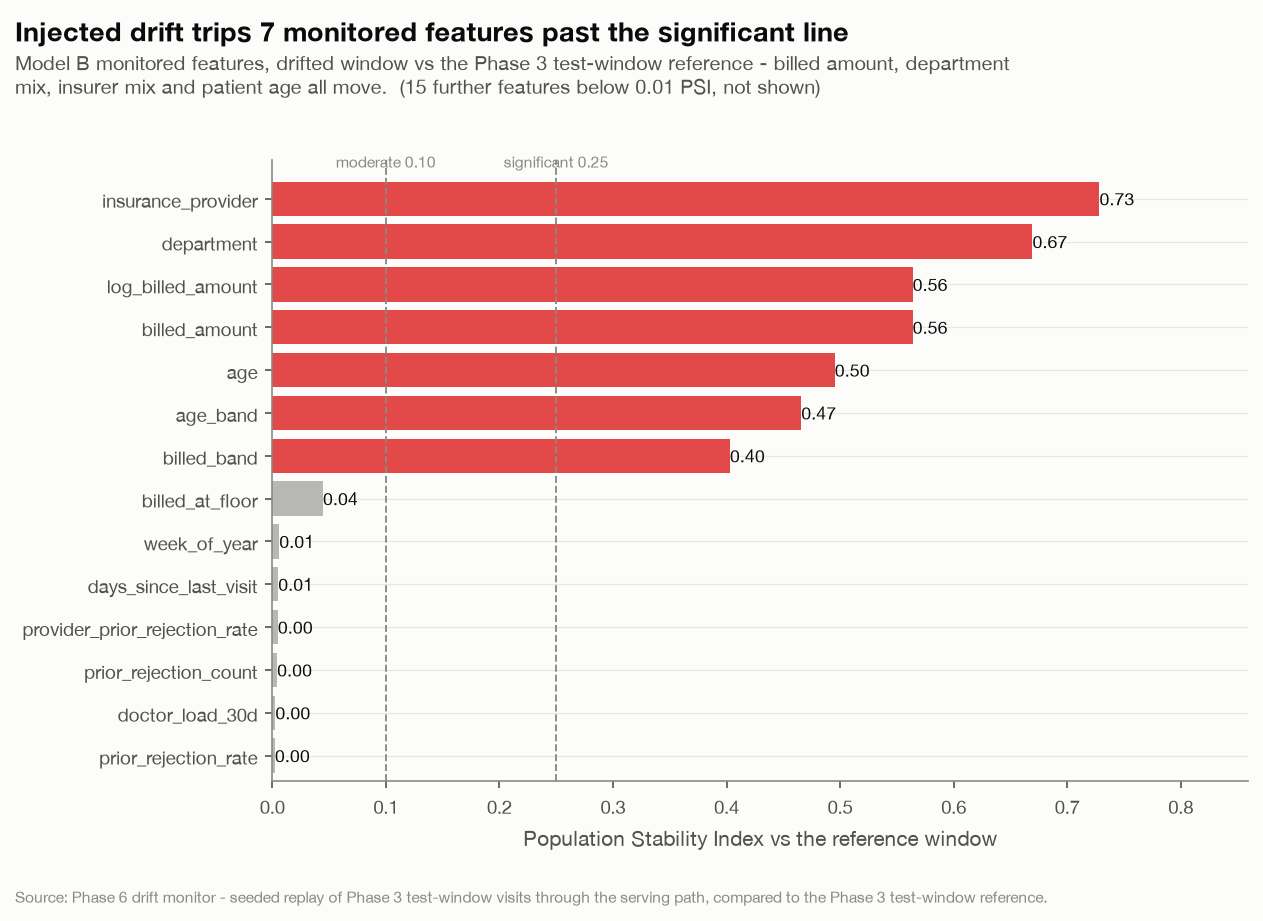

In [13]:
Image(str(_C["feature_psi_drift"]))

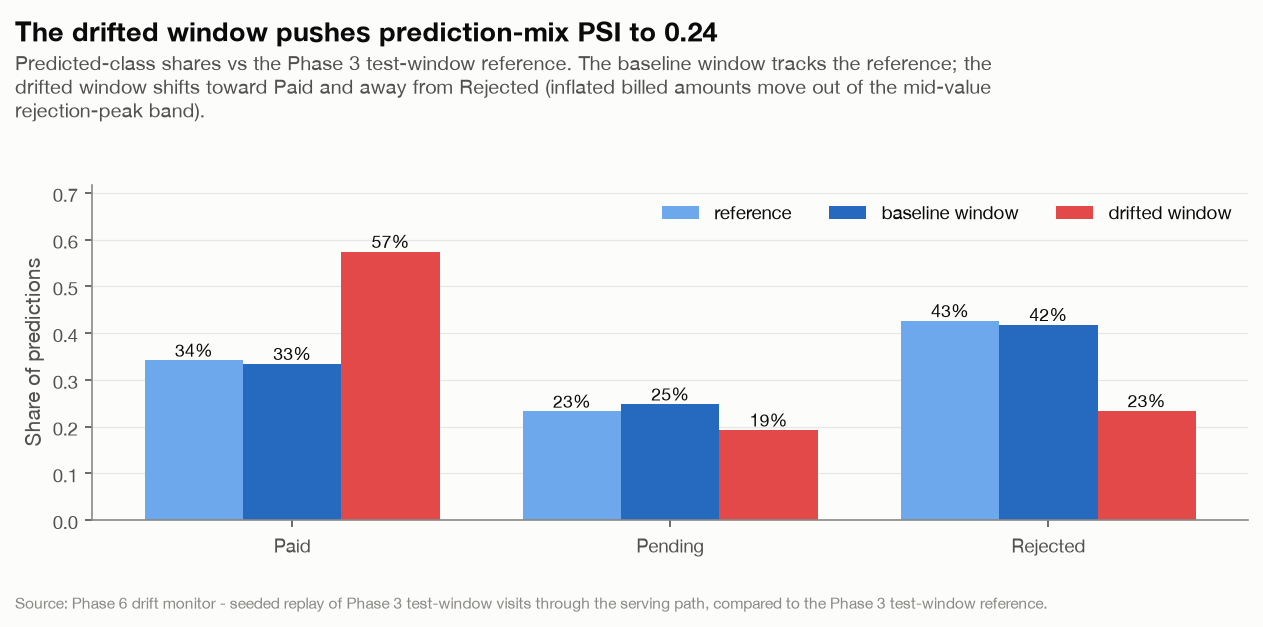

In [14]:
Image(str(_C["prediction_mix"]))

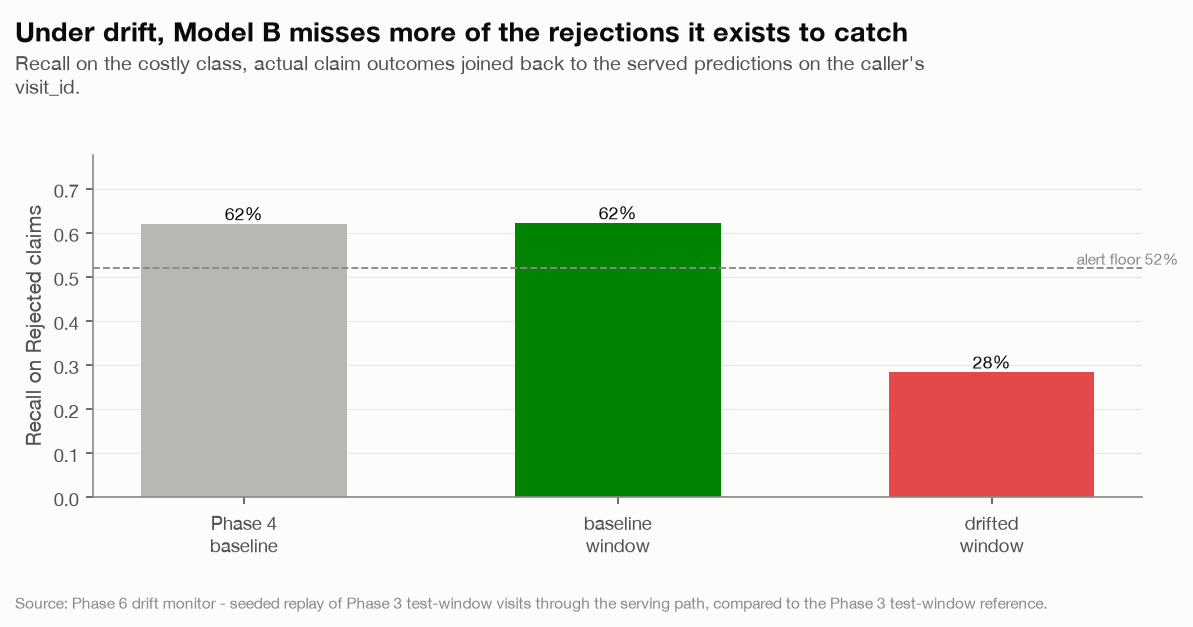

In [15]:
Image(str(_C["performance_drift"]))

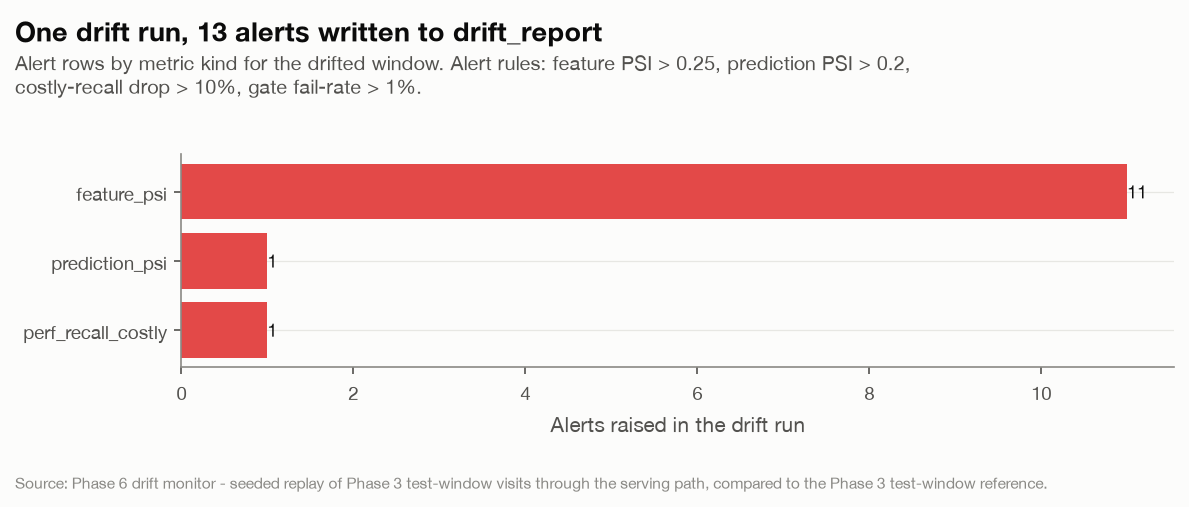

In [16]:
Image(str(_C["alert_summary"]))

## 10. Exit criteria

- [x] Data validation gate on incoming requests (range / enum / schema),
      reusing the Phase 2 rule registry (section 3).
- [x] Drift monitoring off `prediction_log`: feature drift (PSI / KS vs the
      Phase 3 reference), prediction-distribution drift, and performance drift
      once outcomes are joined back (sections 5-7).
- [x] Scheduled drift job + threshold alerts (`phase6_monitoring/scheduler.py`,
      `capstone.monitoring.ALERT_RULES`) - fires on the injected drift.
- [x] `drift_report` table - one append-only row per (run, metric).
- [x] Audit log: `v_prediction_audit` (who / what / when for predictions) +
      `prediction_override` (manual overrides); immutable-by-convention,
      enforced by trigger (section 8).
- [x] Governance docs: `governance.md`, `retraining_policy.md`, `runbook.md`.

**Hand-off to the executive presentation:** the platform is complete
end-to-end. The final phase turns it into a leadership deck - the problem, the
architecture, the SQL + EDA insights, model performance in money and risk
terms, and this monitoring / retraining story.